In [1]:
import pandas as pd
import re
import os

print("🔍 جاري فحص الملفات في بيئة العمل...")
# مسار Colab الافتراضي هو /content/
work_dir = '/content/' if os.path.exists('/content/') else './'
print("📂 الملفات المتاحة حالياً:", os.listdir(work_dir))
print("-" * 40)

# ==========================================
# 1. دالة تنظيف النصوص
# ==========================================
def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = text.replace('#', '')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ==========================================
# 2. دالة تصنيف الكلاس المدمج (6 تصنيفات)
# ==========================================
def get_final_label(sentiment, sarcasm):
    # sentiment: 0 (سلبي), 1 (محايد), 2 (إيجابي)
    # sarcasm: 0 (غير ساخر), 1 (ساخر)
    if sarcasm == 1:
        if sentiment == 0: return 4    # سلبي ساخر
        elif sentiment == 2: return 3  # إيجابي ساخر
        elif sentiment == 1: return 5  # محايد ساخر
    return sentiment # لو غير ساخر، يرجع 0 أو 1 أو 2

# ==========================================
# 3. قراءة الملفات وتوحيدها
# ==========================================
dfs = []

# 1️⃣ ملف Final_Data (sentiment: positive, neutral, negative) - لا يوجد سخرية
try:
    df1_raw = pd.read_csv(os.path.join(work_dir, 'Final_Data.csv'))
    df1 = pd.DataFrame()
    df1['text'] = df1_raw['review_description']
    sentiment_map1 = {'positive': 2, 'neutral': 1, 'negative': 0}
    df1['sentiment'] = df1_raw['rating'].str.lower().map(sentiment_map1)
    df1['sarcasm'] = 0
    dfs.append(df1)
    print("✅ تم قراءة Final_Data.csv")
except Exception as e:
    print(f"❌ لم يتم العثور على Final_Data: {e}")

# 2️⃣ ملف egyptian_sarcasm_data (يحتوي على المشاعر والسخرية معاً)
try:
    df2_raw = pd.read_csv(os.path.join(work_dir, 'egyptian_sarcasm_data.csv'))
    df2 = pd.DataFrame()
    df2['text'] = df2_raw['tweet']
    sentiment_map2 = {'إيجابي': 2, 'محايد': 1, 'سلبي': 0}
    sarcasm_map = {'ساخر': 1, 'غير ساخر': 0}
    df2['sentiment'] = df2_raw['sentiment_label'].map(sentiment_map2)
    df2['sarcasm'] = df2_raw['sarcasm_label'].map(sarcasm_map)
    dfs.append(df2)
    print("✅ تم قراءة egyptian_sarcasm_data.csv")
except Exception as e:
    print(f"❌ لم يتم العثور على egyptian_sarcasm_data: {e}")

# 3️⃣ ملف DATA_SET_CP (1=إيجابي، 0=محايد، -1=سلبي) - لا يوجد سخرية
try:
    df3_raw = pd.read_csv(os.path.join(work_dir, 'DATA_SET_CP.csv'), header=None, names=['text', 'label'])
    df3 = pd.DataFrame()
    df3['text'] = df3_raw['text']
    sentiment_map3 = {1: 2, 0: 1, -1: 0}
    df3['sentiment'] = df3_raw['label'].map(sentiment_map3)
    df3['sarcasm'] = 0
    dfs.append(df3)
    print("✅ تم قراءة DATA_SET_CP.csv")
except Exception as e:
    print(f"❌ لم يتم العثور على DATA_SET_CP: {e}")

# 4️⃣ ملف Tweets_3Classes (1=إيجابي، 2=محايد، 0=سلبي) - لا يوجد سخرية
try:
    df4_raw = pd.read_csv(os.path.join(work_dir, 'Tweets_3Classes.csv'))
    df4 = pd.DataFrame()
    df4['text'] = df4_raw['text']
    def map_tweets(x):
        if x == 1: return 2
        elif x == 2: return 1
        else: return 0
    df4['sentiment'] = df4_raw['label'].apply(map_tweets)
    df4['sarcasm'] = 0
    dfs.append(df4)
    print("✅ تم قراءة Tweets_3Classes.csv")
except Exception as e:
    print(f"❌ لم يتم العثور على Tweets_3Classes: {e}")

# ==========================================
# 4. دمج البيانات وإنشاء التصنيف النهائي
# ==========================================
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)

    # تنظيف النصوص
    combined_df['text'] = combined_df['text'].apply(clean_arabic_text)

    # حذف الصفوف الفارغة
    combined_df.dropna(subset=['text', 'sentiment'], inplace=True)
    combined_df = combined_df[combined_df['text'] != '']

    # تحويل الأنواع
    combined_df['sentiment'] = combined_df['sentiment'].astype(int)
    combined_df['sarcasm'] = combined_df['sarcasm'].fillna(0).astype(int)

    # 🔥 تطبيق معادلة التصنيف المدمج 🔥
    combined_df['final_label'] = combined_df.apply(
        lambda row: get_final_label(row['sentiment'], row['sarcasm']), axis=1
    )

    # الاحتفاظ فقط بالنص والتصنيف النهائي
    final_dataset = combined_df[['text', 'final_label']]

    # حفظ الملف
    final_path = os.path.join(work_dir, 'Unified_Dataset_6Classes.csv')
    final_dataset.to_csv(final_path, index=False, encoding='utf-8')

    print("-" * 40)
    print("🎉 تم الدمج بنجاح!")
    print(f"إجمالي عدد النصوص: {len(final_dataset)}")
    print("\n📊 توزيع التصنيفات النهائية:")
    print("0: سلبي | 1: محايد | 2: إيجابي | 3: إيجابي ساخر | 4: سلبي ساخر | 5: محايد ساخر")
    print(final_dataset['final_label'].value_counts().sort_index())
    print(f"\n💾 تم حفظ الملف في: {final_path}")
else:
    print("⚠️ لم يتم قراءة أي ملفات. يرجى التأكد من رفعها على Colab.")

🔍 جاري فحص الملفات في بيئة العمل...
📂 الملفات المتاحة حالياً: ['.config', 'DATA_SET_CP.csv', 'Final_Data.csv', 'Tweets_3Classes.csv', 'egyptian_sarcasm_data.csv', 'sample_data']
----------------------------------------
✅ تم قراءة Final_Data.csv
✅ تم قراءة egyptian_sarcasm_data.csv
✅ تم قراءة DATA_SET_CP.csv
✅ تم قراءة Tweets_3Classes.csv
----------------------------------------
🎉 تم الدمج بنجاح!
إجمالي عدد النصوص: 76487

📊 توزيع التصنيفات النهائية:
0: سلبي | 1: محايد | 2: إيجابي | 3: إيجابي ساخر | 4: سلبي ساخر | 5: محايد ساخر
final_label
0    22261
1    12555
2    40872
3       23
4      706
5       70
Name: count, dtype: int64

💾 تم حفظ الملف في: /content/Unified_Dataset_6Classes.csv


In [2]:
from google.colab import files

# تحميل الملف للجهاز عندك
files.download('Unified_Dataset_6Classes.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 16.6 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=e3a5de7630e1343a71b0bea5e06fbecefce5ee571e8f65262df9cb9ade1f86ef
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji
🚀 Training on: cuda
⏳ جاري دمج الـ 3 ملفات المحلية مع داتا Hugging Face...
☁️ جاري تحميل داتا ehab215 من السحابة...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/356 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/491k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5820 [00:00<?, ? examples/s]

...

📊 Train Loss: 0.1414 | Val Loss: 0.2057 | Val F1: 0.8370 | Val Acc: 0.8352
🏆 أعلى F1-Score تم تحقيقه! جاري الحفظ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


======== Epoch 4/5 ========


📊 Train Loss: 0.0840 | Val Loss: 0.2657 | Val F1: 0.8325 | Val Acc: 0.8311

======== Epoch 5/5 ========


📊 Train Loss: 0.0476 | Val Loss: 0.3422 | Val F1: 0.8309 | Val Acc: 0.8294

📈 جاري إنشاء رسومات التحليل (Graphs)...


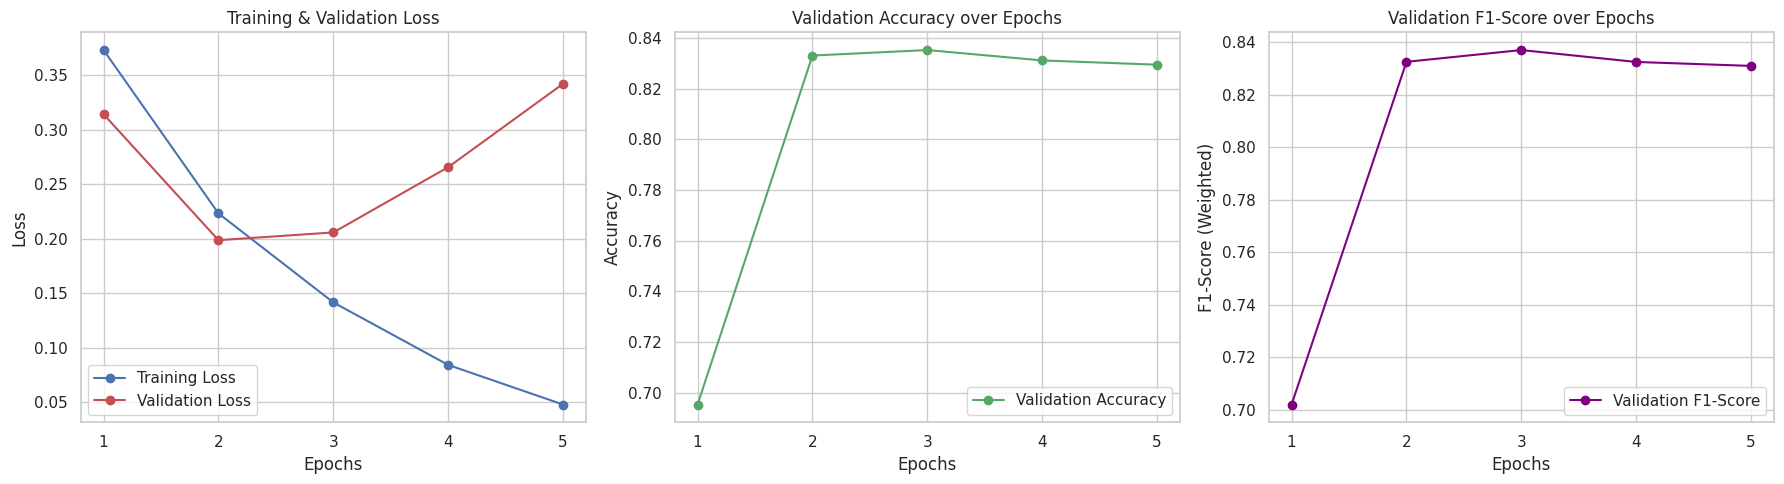


📊 جاري إنشاء مصفوفة الارتباك (Confusion Matrix)...


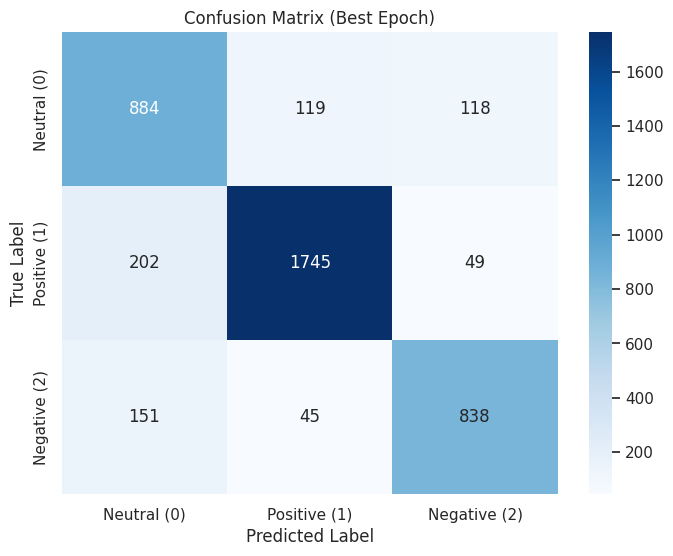


📝 تقرير التصنيف التفصيلي لأفضل نموذج:
              precision    recall  f1-score   support

 Neutral (0)       0.71      0.79      0.75      1121
Positive (1)       0.91      0.87      0.89      1996
Negative (2)       0.83      0.81      0.82      1034

    accuracy                           0.84      4151
   macro avg       0.82      0.82      0.82      4151
weighted avg       0.84      0.84      0.84      4151



In [3]:
# ==========================================
# 1. تسطيب المكتبات واستدعاؤها
# ==========================================
!pip install datasets emoji arabert transformers[torch] scikit-learn pandas matplotlib seaborn pyarabic PyStemmer

import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset

import pyarabic.araby as ar
import Stemmer
import functools
import operator

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import torch.optim as optim
from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# ==========================================
# 2. إعدادات الموديل
# ==========================================
MODEL_NAME = "UBC-NLP/MARBERTv2"
MAX_LEN = 128
BATCH_SIZE = 32
TEST_SIZE = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training on: {DEVICE}")

# ==========================================
# 3. تحميل وتجهيز البيانات
# ==========================================
print("⏳ جاري دمج الـ 3 ملفات المحلية مع داتا Hugging Face...")

# (نفس كود دمج البيانات الخاص بك بدون تغيير)
df1 = pd.read_csv('DATA_SET_CP.csv', header=None, names=['text', 'label'])
df1['label'] = df1['label'].map({1: 1, -1: 2, 0: 0})

try:
    df2 = pd.read_csv('egyptian_sarcasm_data.csv')
    if 'tweet' in df2.columns: df2 = df2.rename(columns={'tweet': 'text'})
    df2['label'] = df2['sentiment_label'].map({'إيجابي': 1, 'سلبي': 2, 'محايد': 0})
    df2 = df2[['text', 'label']]
except:
    df2 = pd.DataFrame(columns=['text', 'label'])

try:
    df3 = pd.read_csv('Tweets_3Classes.csv')
    df3['label'] = df3['label'].map({1: 1, 0: 2, 2: 0})
    df3 = df3[['text', 'label']]
except:
    df3 = pd.DataFrame(columns=['text', 'label'])

print("☁️ جاري تحميل داتا ehab215 من السحابة...")
ds_ehab = load_dataset("ehab215/egyptian_sentiment_analysis_dataset")
df4 = pd.DataFrame(ds_ehab['train'])

if 'tweet' in df4.columns: df4 = df4.rename(columns={'tweet': 'text'})
if 'sentiment' in df4.columns: df4 = df4.rename(columns={'sentiment': 'label'})
elif 'class' in df4.columns: df4 = df4.rename(columns={'class': 'label'})

def safe_map(val):
    v_str = str(val).lower().strip()
    if v_str in ['positive', 'pos', 'إيجابي', '1']: return 1
    if v_str in ['negative', 'neg', 'سلبي', '2', '-1']: return 2
    if v_str in ['neutral', 'neu', 'محايد', '0']: return 0
    return None

df4['label'] = df4['label'].apply(safe_map)
df4 = df4[['text', 'label']].dropna()

df_all = pd.concat([df1, df2, df3, df4], ignore_index=True).dropna()
print(f"📊 عدد البيانات الكلي قبل التنقية: {len(df_all)}")
df_all = df_all.drop_duplicates()
text_counts = df_all.groupby('text')['label'].nunique()
conflicting_texts = text_counts[text_counts > 1].index
df_all = df_all[~df_all['text'].isin(conflicting_texts)]
print(f"🧹 عدد البيانات بعد مسح التضارب: {len(df_all)}")

df_train, df_val = train_test_split(df_all, test_size=TEST_SIZE, random_state=42, stratify=df_all['label'])
df_train['label'] = df_train['label'].astype(int)
df_val['label'] = df_val['label'].astype(int)
print(f"✅ جاهز للتدريب بـ: {len(df_train)} تويتة | التقييم بـ: {len(df_val)} تويتة")

# ==========================================
# 4. تنظيف النصوص
# ==========================================
print("⏳ جاري تهيئة منظف النصوص وبناء الجذور...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
st = Stemmer.Stemmer('arabic')

def champion_clean_text(text):
    if pd.isna(text) or not isinstance(text, str): return ""
    text = re.sub(r'^https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r"^\d+\W+|\b\d+\b|\W+\d+$", "", text)
    text = ar.strip_tashkeel(text)
    text = ar.strip_tatweel(text)
    text = text.replace("#", " ").replace("@", " ").replace("_", " ")
    em_split_emoji = emoji.get_emoji_regexp().split(text)
    em_split_whitespace = [substr.split() for substr in em_split_emoji]
    text = " ".join(functools.reduce(operator.concat, em_split_whitespace))
    text = re.sub(r'(.)\1+', r'\1\1', text)
    text_stem = " ".join([st.stemWord(i) for i in text.split()])
    text = text +" "+ text_stem
    text = text.replace("آ", "ا").replace("إ", "ا").replace("أ", "ا")
    text = text.replace("ؤ", "و").replace("ئ", "ي")
    return text.strip()

df_train['text'] = df_train['text'].apply(champion_clean_text)
df_val['text'] = df_val['text'].apply(champion_clean_text)

# ==========================================
# 5. تجهيز البيانات والـ Focal Loss
# ==========================================
class AdvancedSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]), add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

train_loader = DataLoader(AdvancedSentimentDataset(df_train['text'], df_train['label'], tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AdvancedSentimentDataset(df_val['text'], df_val['label'], tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

class_weights = compute_class_weight('balanced', classes=np.unique(df_train['label']), y=df_train['label'])
loss_fn = FocalLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(DEVICE), gamma=2.0).to(DEVICE)

# ==========================================
# 6. هندسة التدريب (مع تخزين المتركس للرسم)
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(DEVICE)

def train_epoch(model, dataloader, optimizer, scheduler):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids, attention_mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(input_ids, attention_mask=attention_mask).logits, labels)
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler: scheduler.step()
    return total_loss / len(dataloader)

def eval_model(model, dataloader):
    model.eval()
    val_preds, val_true, total_val_loss = [], [], 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating", leave=False):
            input_ids, attention_mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            logits = model(input_ids, attention_mask=attention_mask).logits
            total_val_loss += loss_fn(logits, labels).item()
            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    acc = accuracy_score(val_true, val_preds)
    f1 = f1_score(val_true, val_preds, average='weighted')
    return total_val_loss / len(dataloader), acc, f1, val_true, val_preds

# قواميس لحفظ النتائج لرسمها لاحقاً
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
best_preds, best_true = [], []
save_path = "./Amr_MARBERTv2_Ultimate_Champion"
total_epochs = 5

# --- اللفة الأولى (Frozen BERT) ---
print("\n❄️ ======== Epoch 1/5: Frozen BERT (Training Head Only) ========")
for name, param in model.named_parameters():
    if 'classifier' not in name: param.requires_grad = False

optimizer_head = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
t_loss = train_epoch(model, train_loader, optimizer_head, None)
v_loss, v_acc, v_f1, v_true, v_preds = eval_model(model, val_loader)

history['train_loss'].append(t_loss)
history['val_loss'].append(v_loss)
history['val_acc'].append(v_acc)
history['val_f1'].append(v_f1)
print(f"📊 Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val F1: {v_f1:.4f} | Val Acc: {v_acc:.4f}")

# --- اللفات الجاية (Full Fine-tuning) ---
print("\n🔥 ======== Epoch 2 to 5: Unfrozen BERT (Full Fine-tuning) ========")
for param in model.parameters(): param.requires_grad = True

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in list(model.named_parameters()) if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in list(model.named_parameters()) if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer_full = optim.AdamW(optimizer_grouped_parameters, lr=1.78e-5)
scheduler = get_linear_schedule_with_warmup(optimizer_full, num_warmup_steps=int(0.1 * len(train_loader) * 4), num_training_steps=len(train_loader) * 4)

for epoch in range(2, total_epochs + 1):
    print(f"\n======== Epoch {epoch}/{total_epochs} ========")
    t_loss = train_epoch(model, train_loader, optimizer_full, scheduler)
    v_loss, v_acc, v_f1, v_true, v_preds = eval_model(model, val_loader)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    history['val_f1'].append(v_f1)

    print(f"📊 Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val F1: {v_f1:.4f} | Val Acc: {v_acc:.4f}")

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_preds, best_true = v_preds, v_true
        print(f"🏆 أعلى F1-Score تم تحقيقه! جاري الحفظ...")
        if not os.path.exists(save_path): os.makedirs(save_path)
        model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)

# ==========================================
# 7. التحليل واستخراج الرسومات البيانية (Visualizations)
# ==========================================
print("\n📈 جاري إنشاء رسومات التحليل (Graphs)...")

epochs_range = range(1, total_epochs + 1)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 5))

# 1. رسمة الـ Loss (Train vs Val)
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o', color='b')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o', color='r')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()

# 2. رسمة الـ Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o', color='g')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend()

# 3. رسمة الـ F1-Score
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['val_f1'], label='Validation F1-Score', marker='o', color='purple')
plt.title('Validation F1-Score over Epochs')
plt.xlabel('Epochs')
plt.ylabel('F1-Score (Weighted)')
plt.xticks(epochs_range)
plt.legend()

plt.tight_layout()
plt.show()

# 4. رسمة الـ Confusion Matrix لأفضل نتيجة
print("\n📊 جاري إنشاء مصفوفة الارتباك (Confusion Matrix)...")
cm = confusion_matrix(best_true, best_preds)
class_names = ['Neutral (0)', 'Positive (1)', 'Negative (2)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Best Epoch)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. التقرير التفصيلي (Classification Report)
print("\n📝 تقرير التصنيف التفصيلي لأفضل نموذج:")
print(classification_report(best_true, best_preds, target_names=class_names))

In [4]:
import shutil
import os
from google.colab import files # لو شغال على Colab

# 1. تحديد اسم المجلد اللي سيفنا فيه الموديل واسم ملف الـ zip
folder_to_zip = './Amr_MARBERTv2_Ultimate_Champion'
output_filename = 'Amr_MARBERTv2_Ultimate_Champion_84_F1'

print(f"⏳ جاري ضغط المجلد {folder_to_zip}...")

# 2. عملية الضغط
try:
    shutil.make_archive(output_filename, 'zip', folder_to_zip)
    print(f"✅ تم الضغط بنجاح! الملف جاهز: {output_filename}.zip")

    # 3. أمر التحميل (للـ Colab)
    print("📥 جاري بدء التحميل...")
    files.download(f"{output_filename}.zip")

except Exception as e:
    print(f"❌ حصلت مشكلة أثناء الضغط: {e}")

⏳ جاري ضغط المجلد ./Amr_MARBERTv2_Ultimate_Champion...
✅ تم الضغط بنجاح! الملف جاهز: Amr_MARBERTv2_Ultimate_Champion_84_F1.zip
📥 جاري بدء التحميل...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>